In [154]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [155]:
# project folders
PROJECT_DIR = Path.cwd()
PROCESSED_DIR = PROJECT_DIR / "data_processed"
FIG_DIR = PROJECT_DIR / "figures"

FIG_DIR.mkdir(exist_ok=True)

print("Project folder:", PROJECT_DIR)

Project folder: /Users/aanchal


In [156]:
# load processed files from notebook 1 and notebook 2
daily_crash = pd.read_csv(PROCESSED_DIR / "crash_daily_aggregated.csv")
daily_weather = pd.read_csv(PROCESSED_DIR / "openmeteo_daily_jan_jun_2025.csv")
crash_selected = pd.read_csv(PROCESSED_DIR / "crash_selected_columns.csv")

print("daily_crash shape:", daily_crash.shape)
print("daily_weather shape:", daily_weather.shape)
print("crash_selected shape:", crash_selected.shape)

daily_crash shape: (181, 7)
daily_weather shape: (181, 11)
crash_selected shape: (53608, 17)


In [157]:
# parse dates
daily_crash["crash_day"] = pd.to_datetime(daily_crash["crash_day"])
daily_weather["crash_day"] = pd.to_datetime(daily_weather["crash_day"])
crash_selected["crash_day"] = pd.to_datetime(crash_selected["crash_day"])

daily_crash.head()

,crash_day,daily_crash_count,daily_injuries_total,daily_injuries_fatal,daily_injuries_incapacitating,daily_unknown_weather_count,daily_unknown_surface_count
0,2025-01-01,26,5.0,0.0,1.0,0,4
1,2025-01-02,188,46.0,0.0,1.0,27,28
2,2025-01-03,209,33.0,0.0,2.0,23,39
3,2025-01-04,207,37.0,0.0,3.0,24,35
4,2025-01-05,186,31.0,1.0,3.0,14,25


In [158]:
# merge crash daily data with weather daily data
merged = daily_crash.merge(daily_weather, on="crash_day", how="left")

merged["daily_unknown_weather_share"] = (
    merged["daily_unknown_weather_count"] / merged["daily_crash_count"]
).replace([np.inf, -np.inf], np.nan)

merged["daily_unknown_surface_share"] = (
    merged["daily_unknown_surface_count"] / merged["daily_crash_count"]
).replace([np.inf, -np.inf], np.nan)

merged.head()

,crash_day,daily_crash_count,daily_injuries_total,daily_injuries_fatal,daily_injuries_incapacitating,daily_unknown_weather_count,daily_unknown_surface_count,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours,wet_day,snow_day,daily_unknown_weather_share,daily_unknown_surface_share
0,2025-01-01,26,5.0,0.0,1.0,0,4,71,-1.1,0.8,-3.0,0.1,0.0,0.07,1.0,1,1,0.000000,0.153846
1,2025-01-02,188,46.0,0.0,1.0,27,28,71,-2.4,-0.3,-4.2,0.2,0.0,0.14,2.0,1,1,0.143617,0.148936
2,2025-01-03,209,33.0,0.0,2.0,23,39,3,-4.9,-3.0,-6.9,0.0,0.0,0.00,0.0,0,0,0.110048,0.186603
3,2025-01-04,207,37.0,0.0,3.0,24,35,3,-8.0,-5.1,-10.9,0.0,0.0,0.00,0.0,0,0,0.115942,0.169082
4,2025-01-05,186,31.0,1.0,3.0,14,25,71,-6.6,-2.3,-9.0,0.4,0.1,0.21,3.0,1,1,0.075269,0.134409


In [159]:
# integration checks
integration_summary = pd.DataFrame({
    "metric": [
        "merged_rows",
        "expected_days_from_crash_daily",
        "weather_days_available",
        "matched_weather_rows",
        "missing_weather_rows_after_merge",
        "min_merged_day",
        "max_merged_day"
    ],
    "value": [
        merged.shape[0],
        daily_crash.shape[0],
        daily_weather.shape[0],
        merged["precipitation_sum"].notna().sum(),
        merged["precipitation_sum"].isna().sum(),
        merged["crash_day"].min(),
        merged["crash_day"].max()
    ]
})

integration_summary

,metric,value
0,merged_rows,181
1,expected_days_from_crash_daily,181
2,weather_days_available,181
3,matched_weather_rows,181
4,missing_weather_rows_after_merge,0
5,min_merged_day,2025-01-01 00:00:00
6,max_merged_day,2025-06-30 00:00:00


In [160]:
# save merged data and integration summary
merged.to_csv(PROCESSED_DIR / "crash_weather_integrated.csv", index=False)
integration_summary.to_csv(PROCESSED_DIR / "integration_summary.csv", index=False)

print("Saved:")
print(PROCESSED_DIR / "crash_weather_integrated.csv")
print(PROCESSED_DIR / "integration_summary.csv")

Saved:
/Users/aanchal/data_processed/crash_weather_integrated.csv
/Users/aanchal/data_processed/integration_summary.csv


In [161]:
# wet vs dry summary
wet_dry_summary = (
    merged.groupby("wet_day")
    .agg(
        day_count=("crash_day", "count"),
        avg_daily_crashes=("daily_crash_count", "mean"),
        median_daily_crashes=("daily_crash_count", "median"),
        avg_daily_injuries_total=("daily_injuries_total", "mean"),
        avg_daily_fatal_injuries=("daily_injuries_fatal", "mean"),
        avg_unknown_weather_share=("daily_unknown_weather_share", "mean"),
        avg_unknown_surface_share=("daily_unknown_surface_share", "mean")
    )
    .reset_index()
)

wet_dry_summary["wet_day_label"] = wet_dry_summary["wet_day"].map({0: "Dry", 1: "Wet"})
wet_dry_summary

,wet_day,day_count,avg_daily_crashes,median_daily_crashes,avg_daily_injuries_total,avg_daily_fatal_injuries,avg_unknown_weather_share,avg_unknown_surface_share,wet_day_label
0,0,87,285.724138,289.0,65.425287,0.252874,0.081294,0.149525,Dry
1,1,94,305.851064,312.0,65.372340,0.202128,0.087517,0.145975,Wet


In [162]:
wet_dry_summary.to_csv(PROCESSED_DIR / "wet_dry_summary.csv", index=False)
print(PROCESSED_DIR / "wet_dry_summary.csv")

/Users/aanchal/data_processed/wet_dry_summary.csv


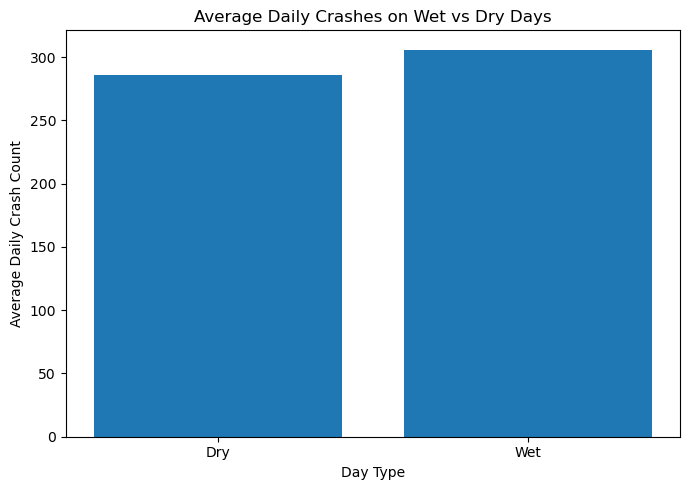

In [163]:
# plot average daily crashes on wet vs dry days
plot_df = wet_dry_summary.sort_values("wet_day")

plt.figure(figsize=(7, 5))
plt.bar(plot_df["wet_day_label"], plot_df["avg_daily_crashes"])
plt.title("Average Daily Crashes on Wet vs Dry Days")
plt.xlabel("Day Type")
plt.ylabel("Average Daily Crash Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "wet_vs_dry_daily_crashes.png", dpi=200)
plt.show()

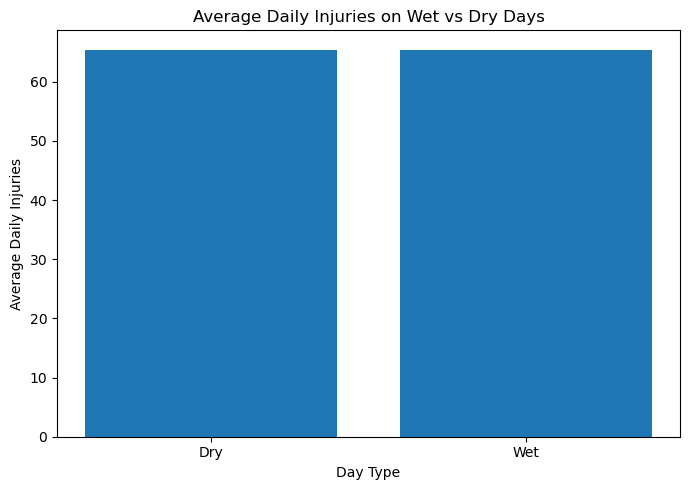

In [164]:
# plot average daily injuries on wet vs dry days
plt.figure(figsize=(7, 5))
plt.bar(plot_df["wet_day_label"], plot_df["avg_daily_injuries_total"])
plt.title("Average Daily Injuries on Wet vs Dry Days")
plt.xlabel("Day Type")
plt.ylabel("Average Daily Injuries")
plt.tight_layout()
plt.savefig(FIG_DIR / "wet_vs_dry_daily_injuries.png", dpi=200)
plt.show()

In [165]:
# clean officer-reported weather field for consistency checks
crash_selected["WEATHER_CONDITION"] = crash_selected["WEATHER_CONDITION"].astype(str).str.strip()

# daily shares of officer-reported weather categories
weather_daily = (
    crash_selected.groupby("crash_day")
    .agg(
        crash_count=("CRASH_RECORD_ID", "count"),
        clear_count=("WEATHER_CONDITION", lambda s: (s == "CLEAR").sum()),
        unknown_other_count=("WEATHER_CONDITION", lambda s: s.isin(["UNKNOWN", "OTHER"]).sum()),
        rain_count=("WEATHER_CONDITION", lambda s: (s == "RAIN").sum()),
        snow_like_count=("WEATHER_CONDITION", lambda s: s.isin(["SNOW", "FREEZING RAIN/DRIZZLE", "SLEET/HAIL", "BLOWING SNOW"]).sum())
    )
    .reset_index()
)

weather_daily["clear_share"] = weather_daily["clear_count"] / weather_daily["crash_count"]
weather_daily["unknown_other_share"] = weather_daily["unknown_other_count"] / weather_daily["crash_count"]
weather_daily["rain_share"] = weather_daily["rain_count"] / weather_daily["crash_count"]
weather_daily["snow_like_share"] = weather_daily["snow_like_count"] / weather_daily["crash_count"]

weather_daily.head()

,crash_day,crash_count,clear_count,unknown_other_count,rain_count,snow_like_count,clear_share,unknown_other_share,rain_share,snow_like_share
0,2025-01-01,26,23,0,0,1,0.884615,0.000000,0.000000,0.038462
1,2025-01-02,188,124,27,4,30,0.659574,0.143617,0.021277,0.159574
2,2025-01-03,209,171,23,1,12,0.818182,0.110048,0.004785,0.057416
3,2025-01-04,207,179,24,1,0,0.864734,0.115942,0.004831,0.000000
4,2025-01-05,186,123,14,0,36,0.661290,0.075269,0.000000,0.193548


In [166]:
# merge daily crash-weather data with daily officer-weather shares
consistency_df = merged.merge(
    weather_daily[
        [
            "crash_day",
            "clear_share",
            "unknown_other_share",
            "rain_share",
            "snow_like_share"
        ]
    ],
    on="crash_day",
    how="left"
)

consistency_df.head()

,crash_day,daily_crash_count,daily_injuries_total,daily_injuries_fatal,daily_injuries_incapacitating,daily_unknown_weather_count,daily_unknown_surface_count,weather_code,temperature_2m_mean,temperature_2m_max,...,snowfall_sum,precipitation_hours,wet_day,snow_day,daily_unknown_weather_share,daily_unknown_surface_share,clear_share,unknown_other_share,rain_share,snow_like_share
0,2025-01-01,26,5.0,0.0,1.0,0,4,71,-1.1,0.8,...,0.07,1.0,1,1,0.000000,0.153846,0.884615,0.000000,0.000000,0.038462
1,2025-01-02,188,46.0,0.0,1.0,27,28,71,-2.4,-0.3,...,0.14,2.0,1,1,0.143617,0.148936,0.659574,0.143617,0.021277,0.159574
2,2025-01-03,209,33.0,0.0,2.0,23,39,3,-4.9,-3.0,...,0.00,0.0,0,0,0.110048,0.186603,0.818182,0.110048,0.004785,0.057416
3,2025-01-04,207,37.0,0.0,3.0,24,35,3,-8.0,-5.1,...,0.00,0.0,0,0,0.115942,0.169082,0.864734,0.115942,0.004831,0.000000
4,2025-01-05,186,31.0,1.0,3.0,14,25,71,-6.6,-2.3,...,0.21,3.0,1,1,0.075269,0.134409,0.661290,0.075269,0.000000,0.193548


In [167]:
# compare officer-reported categories on measured wet vs dry days
consistency_summary = (
    consistency_df.groupby("wet_day")
    .agg(
        avg_clear_share=("clear_share", "mean"),
        avg_unknown_other_share=("unknown_other_share", "mean"),
        avg_rain_share=("rain_share", "mean"),
        avg_snow_like_share=("snow_like_share", "mean")
    )
    .reset_index()
)

consistency_summary["wet_day_label"] = consistency_summary["wet_day"].map({0: "Dry", 1: "Wet"})
consistency_summary

,wet_day,avg_clear_share,avg_unknown_other_share,avg_rain_share,avg_snow_like_share,wet_day_label
0,0,0.888075,0.081294,0.004032,0.010788,Dry
1,1,0.674457,0.087517,0.122776,0.067517,Wet


In [168]:
consistency_summary.to_csv(PROCESSED_DIR / "weather_consistency_summary.csv", index=False)
print(PROCESSED_DIR / "weather_consistency_summary.csv")

/Users/aanchal/data_processed/weather_consistency_summary.csv


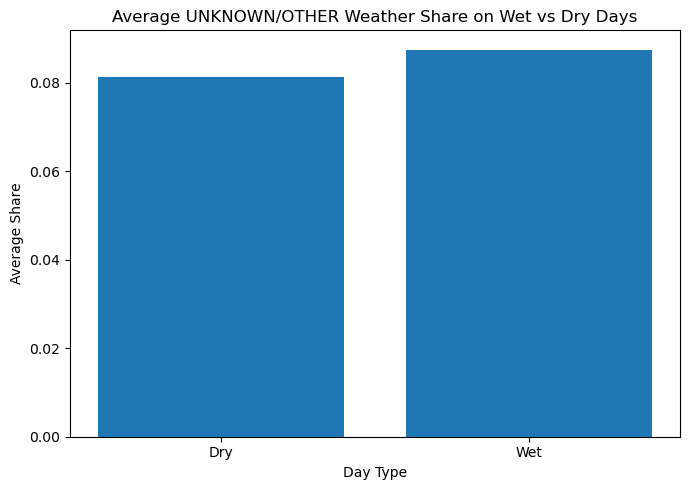

In [169]:
# plot average UNKNOWN/OTHER share on wet vs dry days
plt.figure(figsize=(7, 5))
plt.bar(consistency_summary["wet_day_label"], consistency_summary["avg_unknown_other_share"])
plt.title("Average UNKNOWN/OTHER Weather Share on Wet vs Dry Days")
plt.xlabel("Day Type")
plt.ylabel("Average Share")
plt.tight_layout()
plt.savefig(FIG_DIR / "wet_vs_dry_unknown_weather_share.png", dpi=200)
plt.show()

In [170]:
# optional quick summary to use in report
final_quick_summary = pd.DataFrame({
    "metric": [
        "merged_day_count",
        "unmatched_weather_days_after_merge",
        "wet_day_count",
        "dry_day_count",
        "avg_daily_crashes_wet_days",
        "avg_daily_crashes_dry_days",
        "avg_daily_injuries_wet_days",
        "avg_daily_injuries_dry_days"
    ],
    "value": [
        merged.shape[0],
        int(merged["precipitation_sum"].isna().sum()),
        int((merged["wet_day"] == 1).sum()),
        int((merged["wet_day"] == 0).sum()),
        float(wet_dry_summary.loc[wet_dry_summary["wet_day"] == 1, "avg_daily_crashes"].iloc[0]),
        float(wet_dry_summary.loc[wet_dry_summary["wet_day"] == 0, "avg_daily_crashes"].iloc[0]),
        float(wet_dry_summary.loc[wet_dry_summary["wet_day"] == 1, "avg_daily_injuries_total"].iloc[0]),
        float(wet_dry_summary.loc[wet_dry_summary["wet_day"] == 0, "avg_daily_injuries_total"].iloc[0]),
    ]
})

final_quick_summary

,metric,value
0,merged_day_count,181.000000
1,unmatched_weather_days_after_merge,0.000000
2,wet_day_count,94.000000
3,dry_day_count,87.000000
4,avg_daily_crashes_wet_days,305.851064
5,avg_daily_crashes_dry_days,285.724138
6,avg_daily_injuries_wet_days,65.372340
7,avg_daily_injuries_dry_days,65.425287


In [171]:
final_quick_summary.to_csv(PROCESSED_DIR / "final_quick_summary.csv", index=False)
print(PROCESSED_DIR / "final_quick_summary.csv")

/Users/aanchal/data_processed/final_quick_summary.csv


In [172]:
# ── SCENARIO A: officer-reported weather classification ──────────────
crash_sel = pd.read_csv(PROCESSED_DIR / "crash_selected_columns.csv")
crash_sel["crash_day"] = pd.to_datetime(crash_sel["crash_day"], errors="coerce")
crash_sel["WEATHER_CONDITION"] = crash_sel["WEATHER_CONDITION"].astype(str).str.strip().str.upper()
crash_sel["INJURIES_TOTAL"] = pd.to_numeric(crash_sel["INJURIES_TOTAL"], errors="coerce")

wet_officer_cats = ["RAIN", "SNOW", "FREEZING RAIN/DRIZZLE", "SLEET/HAIL", "BLOWING SNOW"]
crash_sel["officer_wet"] = crash_sel["WEATHER_CONDITION"].isin(wet_officer_cats).astype(int)

daily_officer = (
    crash_sel.groupby("crash_day")
    .agg(
        daily_crash_count=("CRASH_RECORD_ID", "count"),
        daily_injuries_total=("INJURIES_TOTAL", "sum"),
        officer_wet_count=("officer_wet", "sum"),
    )
    .reset_index()
)
daily_officer["officer_wet_day"] = (
    daily_officer["officer_wet_count"] / daily_officer["daily_crash_count"] >= 0.20
).astype(int)

scenario_A = (
    daily_officer.groupby("officer_wet_day")
    .agg(
        day_count=("crash_day", "count"),
        avg_crashes=("daily_crash_count", "mean"),
        median_crashes=("daily_crash_count", "median"),
        avg_injuries=("daily_injuries_total", "mean"),
    )
    .reset_index()
    .rename(columns={"officer_wet_day": "wet_day"})
)
scenario_A["scenario"] = "A: Officer-reported"
print("=== Scenario A ===")
print(scenario_A.to_string(index=False))

=== Scenario A ===
 wet_day  day_count  avg_crashes  median_crashes  avg_injuries            scenario
       0        144   289.527778           295.5     65.465278 A: Officer-reported
       1         37   322.054054           318.0     65.135135 A: Officer-reported


In [173]:
# ── SCENARIO B: Open-Meteo wet day (already in merged) ──────────────
scenario_B = (
    merged.groupby("wet_day")
    .agg(
        day_count=("crash_day", "count"),
        avg_crashes=("daily_crash_count", "mean"),
        median_crashes=("daily_crash_count", "median"),
        avg_injuries=("daily_injuries_total", "mean"),
    )
    .reset_index()
)
scenario_B["scenario"] = "B: Open-Meteo"
print("=== Scenario B: Open-Meteo ===")
print(scenario_B.to_string(index=False))

=== Scenario B: Open-Meteo ===
 wet_day  day_count  avg_crashes  median_crashes  avg_injuries      scenario
       0         87   285.724138           289.0     65.425287 B: Open-Meteo
       1         94   305.851064           312.0     65.372340 B: Open-Meteo


In [174]:
# ── SCENARIO C: sensitivity — exclude high-uncertainty days ─────────
threshold = 0.10
merged_filtered = merged[merged["daily_unknown_weather_share"] <= threshold].copy()

scenario_C = (
    merged_filtered.groupby("wet_day")
    .agg(
        day_count=("crash_day", "count"),
        avg_crashes=("daily_crash_count", "mean"),
        median_crashes=("daily_crash_count", "median"),
        avg_injuries=("daily_injuries_total", "mean"),
    )
    .reset_index()
)
scenario_C["scenario"] = "C: Open-Meteo (low-uncertainty days only)"
print(f"Days excluded (unknown share > {threshold:.0%}): {len(merged) - len(merged_filtered)}")
print(f"Days retained: {len(merged_filtered)}")
print("\n=== Scenario C: Sensitivity ===")
print(scenario_C.to_string(index=False))

Days excluded (unknown share > 10%): 44
Days retained: 137

=== Scenario C: Sensitivity ===
 wet_day  day_count  avg_crashes  median_crashes  avg_injuries                                  scenario
       0         70   295.428571           297.0     68.814286 C: Open-Meteo (low-uncertainty days only)
       1         67   307.283582           317.0     67.432836 C: Open-Meteo (low-uncertainty days only)


In [175]:
# ── Save all scenarios ───────────────────────────────────────────────
scenario_A.to_csv(PROCESSED_DIR / "scenario_A_officer.csv", index=False)
scenario_B.to_csv(PROCESSED_DIR / "scenario_B_openmeteo.csv", index=False)
scenario_C.to_csv(PROCESSED_DIR / "scenario_C_sensitivity.csv", index=False)
pd.concat([scenario_A, scenario_B, scenario_C]).to_csv(
    PROCESSED_DIR / "impact_assessment_combined.csv", index=False)
print("Saved all scenario files.")

Saved all scenario files.


Scenario A wet_day values: [0, 1]
Scenario B wet_day values: [0, 1]
Scenario C wet_day values: [0, 1]


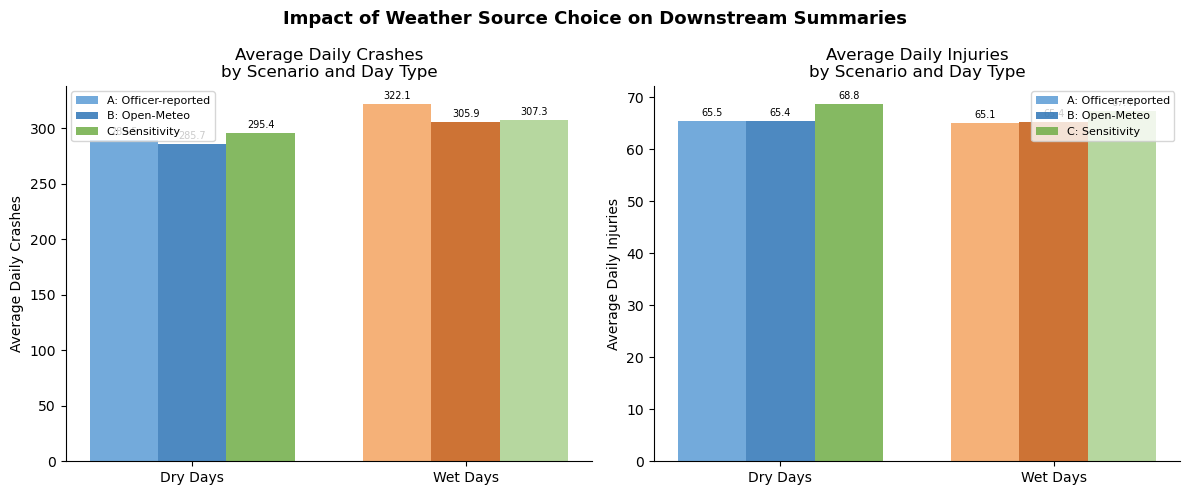

Saved: before_after_scenario_comparison.png


In [176]:
# ── Before/After comparison chart ───────────────────────────────────
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Impact of Weather Source Choice on Downstream Summaries",
             fontsize=13, fontweight="bold")

# Debug: print what values exist in each scenario
print("Scenario A wet_day values:", scenario_A["wet_day"].tolist())
print("Scenario B wet_day values:", scenario_B["wet_day"].tolist())
print("Scenario C wet_day values:", scenario_C["wet_day"].tolist())

for ax, col, ylabel, title in zip(
    axes,
    ["avg_crashes", "avg_injuries"],
    ["Average Daily Crashes", "Average Daily Injuries"],
    ["Average Daily Crashes\nby Scenario and Day Type",
     "Average Daily Injuries\nby Scenario and Day Type"]
):
    x = np.arange(2)
    w = 0.25

    # Use .query() instead of .loc[] to avoid index issues
    dry_A = scenario_A.query("wet_day == 0")[col].values[0]
    wet_A = scenario_A.query("wet_day == 1")[col].values[0]
    dry_B = scenario_B.query("wet_day == 0")[col].values[0]
    wet_B = scenario_B.query("wet_day == 1")[col].values[0]
    dry_C = scenario_C.query("wet_day == 0")[col].values[0]
    wet_C = scenario_C.query("wet_day == 1")[col].values[0]

    b1 = ax.bar(x - w, [dry_A, wet_A], w, label="A: Officer-reported",
                color=["#5B9BD5","#F4A460"], alpha=0.85)
    b2 = ax.bar(x,     [dry_B, wet_B], w, label="B: Open-Meteo",
                color=["#2E75B6","#C55A11"], alpha=0.85)
    b3 = ax.bar(x + w, [dry_C, wet_C], w, label="C: Sensitivity",
                color=["#70AD47","#A9D18E"], alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(["Dry Days", "Wet Days"])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.bar_label(b1, fmt="%.1f", padding=2, fontsize=7)
    ax.bar_label(b2, fmt="%.1f", padding=2, fontsize=7)
    ax.bar_label(b3, fmt="%.1f", padding=2, fontsize=7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / "before_after_scenario_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: before_after_scenario_comparison.png")